In [1]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
import yaml
import re

print("Starting combined preprocessing script...")

# ======================
# Define paths and parameters
# ======================
data_path = r"C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 1"
processed_data_path = r"D:\Per Patient Normalization Output without the first 3 trials"
os.makedirs(processed_data_path, exist_ok=True)
log_file = os.path.join(processed_data_path, "discrepancies_log.yaml")

# Time windows for epochs
iti_tmin, iti_tmax = -1.0, 0.0   # ITI: 1s before stimulus
stim_tmin, stim_tmax = 0.0, 4.5    # Stimulus: 0 to 4.5s after stimulus

# Expected markers
expected_stim_markers = {'13', '11', '12', '120', '110'}
expected_tms_markers = {'134', '114', '124'}

# ======================
# Helper functions
# ======================
def log_discrepancies(log_file, discrepancies):
    with open(log_file, "a") as f:
        yaml.dump(discrepancies, f)

def plot_data(data, title, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(data.T)
    plt.title(title)
    plt.xlabel("Time Points")
    plt.ylabel("Amplitude")
    plt.savefig(save_path)
    plt.close()

def clean_vmrk_file(input_path, output_path):
    """
    Cleans a .vmrk file by keeping only stimulus markers.
    """
    with open(input_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    cleaned_lines = []
    marker_pattern = re.compile(r"^Mk\d+=(Stimulus),(.+?),(\d+),(\d+),(\d+)(,.*)?$")
    process_markers = False

    for line in lines:
        if line.strip().startswith(";") or line.strip() == "" or line.strip().startswith("["):
            cleaned_lines.append(line)
            continue
        
        if line.strip().startswith("Mk2=DC Correction"):
            process_markers = True
            continue

        if process_markers and line.strip().startswith("Mk"):
            match = marker_pattern.match(line.strip())
            if match and match.group(2) in expected_stim_markers:
                marker_type = match.group(1)
                description = match.group(2)
                position = match.group(3)
                size = match.group(4)
                channel = match.group(5)
                extra = match.group(6) or ""
                cleaned_lines.append(f"Mk{len(cleaned_lines)+1}={marker_type},{description},{position},{size},{channel}{extra}\n")
        else:
            print(f"Warning: Ignored invalid or non-stimulus marker line -> {line.strip()}")
    
    with open(output_path, 'w', encoding='utf-8') as file:
        file.writelines(cleaned_lines)
    print(f"Cleaned .vmrk file saved to {output_path}")

# ======================
# Process each participant separately
# ======================
files = os.listdir(data_path)
vhdr_files = [file for file in files if file.endswith('.vhdr')]
print(f"Found {len(vhdr_files)} .vhdr files: {vhdr_files}")

summary_data = []
summary_file = os.path.join(processed_data_path, "marker_summary.txt")

for vhdr_file in vhdr_files:
    # Use the file name (or a slightly modified version) as participant ID
    if vhdr_file == "01_ln_block1.vhdr":
        participant_block = "01_ln_block1"
    else:
        participant_block = os.path.splitext(vhdr_file)[0]
    
    print(f"\nProcessing file: {vhdr_file}")
    print(f"Participant block: {participant_block}")
    
    try:
        # Define file paths for .vhdr, .vmrk, and .eeg
        vhdr_path = os.path.join(data_path, vhdr_file)
        vmrk_path = os.path.join(data_path, participant_block + ".vmrk")
        eeg_path = os.path.join(data_path, participant_block + ".eeg")
        
        print(f"Checking files:\n{vhdr_path}\n{vmrk_path}\n{eeg_path}")
        if not all([os.path.exists(vhdr_path), os.path.exists(vmrk_path), os.path.exists(eeg_path)]):
            print(f"Skipping {vhdr_file}: One or more required files are missing!")
            continue
        
        # Extract markers from the .vmrk file
        markers = []
        with open(vmrk_path, 'r') as file:
            for line in file:
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    description = parts[1].strip()
                    sample = int(parts[2].strip())
                    markers.append((description, sample))
        if markers:
            print("Markers found:", markers)
        else:
            print("No stimulus markers found.")
        
        # Load the raw data (BrainVision format auto-links .vmrk and .eeg)
        raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
        events, event_id = mne.events_from_annotations(raw)
        
        # Filter events for stimulus markers
        stim_events = [event for event in events if str(event[2]) in expected_stim_markers]
        tms_events = [event for event in events if str(event[2]) in expected_tms_markers]
        
        stim_marker_counts = {marker: 0 for marker in expected_stim_markers}
        tms_marker_counts = {marker: 0 for marker in expected_tms_markers}
        for event in stim_events:
            marker = str(event[2])
            stim_marker_counts[marker] += 1
        for event in tms_events:
            marker = str(event[2])
            tms_marker_counts[marker] += 1
        
        print(f"Stimulus marker counts: {stim_marker_counts}")
        print(f"TMS marker counts: {tms_marker_counts}")
        
        if not stim_events:
            print(f"No stimulus markers found for {participant_block}. Skipping file.")
            continue
        
        # Build the events array for Epochs extraction.
        # Each row is: [sample, 0, event_id] where event_id is the marker code.
        stim_events_array = np.array([[event[0], 0, int(event[2])] for event in stim_events])
        
        # -----------------------------
        # Remove the first three trials for each experimental condition
        # -----------------------------
        unique_conditions = np.unique(stim_events_array[:, 2])
        keep_indices = []
        for cond in unique_conditions:
            cond_indices = np.where(stim_events_array[:, 2] == cond)[0]
            if len(cond_indices) > 3:
                keep_indices.extend(cond_indices[3:])  # Discard first 3 trials
            else:
                keep_indices.extend(cond_indices)
        keep_indices = np.sort(keep_indices)
        stim_events_array = stim_events_array[keep_indices]
        # -----------------------------
        
        # Extract ITI epochs and stimulus epochs
        iti_epochs = mne.Epochs(raw, stim_events_array, None, tmin=iti_tmin, tmax=iti_tmax, baseline=None, preload=True)
        print(f"Extracted ITI epochs shape: {iti_epochs.get_data().shape}")
        
        stim_epochs = mne.Epochs(raw, stim_events_array, None, tmin=stim_tmin, tmax=stim_tmax, baseline=None, preload=True)
        print(f"Extracted stimulus epochs shape: {stim_epochs.get_data().shape}")
        
        # ----- STEP 1: ITI Subtraction (Channel-Specific) -----
        if iti_epochs.get_data().size > 0:
            iti_data = iti_epochs.get_data()    # Shape: (n_epochs, n_channels, n_times)
            stim_data = stim_epochs.get_data()    # Shape: (n_epochs, n_channels, n_times)
            # Compute per-channel ITI mean (averaging over epochs and time)
            iti_mean = iti_data.mean(axis=(0, 2), keepdims=True)  # Shape: (1, n_channels, 1)
            iti_subtracted_data = stim_data - iti_mean
            print("Performed ITI subtraction on stimulus data.")
        else:
            print("ITI data empty; skipping ITI subtraction.")
            iti_subtracted_data = stim_epochs.get_data()
        
        # ----- STEP 2: Standard Scaling on the ITI-Subtracted Data -----
        # Performing participant-wise normalization:
        # Compute a single global mean and standard deviation over all epochs, channels, and time points.
        mean_global = iti_subtracted_data.mean()
        std_global = iti_subtracted_data.std()
        normalized_stim_data = (iti_subtracted_data - mean_global) / std_global
        print("Applied participant-wise normalization on ITI-subtracted stimulus data.")
        
        # ----- Save Processed Data and Plots -----
        # Save normalized and raw stimulus data as .npy files
        np.save(os.path.join(processed_data_path, f"{participant_block}_normalized.npy"), normalized_stim_data)
        np.save(os.path.join(processed_data_path, f"{participant_block}_raw.npy"), stim_epochs.get_data())
        print(f"Saved normalized and raw data for {participant_block}.")
        
        # Plot ITI mean vs. stimulus mean (from raw data)
        iti_mean_plot = iti_epochs.get_data().mean(axis=(0, 2))
        stim_mean_plot = stim_epochs.get_data().mean(axis=(0, 2))
        plt.figure(figsize=(10, 5))
        plt.plot(iti_mean_plot, label='ITI Mean', color='blue')
        plt.plot(stim_mean_plot, label='Stimulus Mean', color='orange')
        plt.legend()
        plt.title("Comparison of ITI and Stimulus Means")
        plt.xlabel("Channels")
        plt.ylabel("Amplitude")
        plt.savefig(os.path.join(processed_data_path, f"{participant_block}_iti_vs_stim_means.png"))
        plt.close()
        
        # Plot first trial raw data
        plot_data(stim_epochs.get_data()[0], f"Raw Stimulus Data ({participant_block})",
                  os.path.join(processed_data_path, f"{participant_block}_raw.png"))
        # Plot first trial normalized data
        plot_data(normalized_stim_data[0], f"Normalized Stimulus Data ({participant_block})",
                  os.path.join(processed_data_path, f"{participant_block}_normalized.png"))
        print(f"Saved plots for {participant_block}.")
        
        # Append summary information
        summary_data.append({
            'Participant': participant_block,
            'Stimulus Markers': stim_marker_counts,
            'TMS Markers': tms_marker_counts,
            'Stimulus Data Shape': stim_epochs.get_data().shape,
            'Normalized Data Shape': normalized_stim_data.shape
        })
        
        with open(summary_file, 'w') as file:
            yaml.dump(summary_data, file)
        
    except Exception as e:
        print(f"Error processing {vhdr_file}: {e}")


Starting combined preprocessing script...
Found 30 .vhdr files: ['01_ln_block1.vhdr', '02gd_block1.vhdr', '03as_block1.vhdr', '04ep_block1.vhdr', '05br_block1.vhdr', '06nc_block1.vhdr', '07fs_block1.vhdr', '08am_block1.vhdr', '09dm_block1.vhdr', '10lc_block1.vhdr', '11gb_block1.vhdr', '12ag_block1.vhdr', '13gc_block1.vhdr', '14es_block1.vhdr', '15kf_block1.vhdr', '16gd_block1.vhdr', '17st_block1.vhdr', '18gf_block1.vhdr', '19tm_block1.vhdr', '20md_block1.vhdr', '21es_block1.vhdr', '22mc_block1.vhdr', '23lp_block1.vhdr', '24cs_block1.vhdr', '25vt_block1.vhdr', '26fs_block1.vhdr', '27rv_block1.vhdr', '28gv_block1.vhdr', '29bc_block1.vhdr', '30ss_block1.vhdr']

Processing file: 01_ln_block1.vhdr
Participant block: 01_ln_block1
Checking files:
C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 1\01_ln_block1.vhdr
C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 1\01_ln_block1.vmrk
C:\Users\Asus\Documents\Professor Fr

In [1]:
import os
import re
import numpy as np
import yaml
import matplotlib.pyplot as plt
from scipy.signal import iirfilter, sosfiltfilt

# Configuration
# Directory where the *_normalized.npy files live (post-ITI subtraction & scaling)
normalized_data_path = r"D:\Per Patient Normalization Output without the first 3 trials"

# Directory to save final filtered/downsampled data
filtered_data_path = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
os.makedirs(filtered_data_path, exist_ok=True)

# Filter parameters
low_freq = 0.5    # Hz
high_freq = 50.0  # Hz
order = 4         # Butterworth order

# Original sampling rate *at the time this script runs* 
orig_sfreq = 5000  

# Downsampled rate
new_sfreq = 500    # Changed from 100 to 500 Hz
downsample_factor = orig_sfreq // new_sfreq  # Updated factor from 50 to 10

# Helper Functions

def bandpass_sos(low_hz, high_hz, order, fs):
    """
    Creates second-order sections for a Butterworth bandpass filter.
    fs: sampling rate (Hz)
    """
    from scipy.signal import iirfilter
    nyq = 0.5 * fs
    low  = low_hz / nyq
    high = high_hz / nyq
    sos = iirfilter(order, [low, high], btype='band', ftype='butter', output='sos')
    return sos

def apply_filter_downsample(data_3d, sos, factor):
    """
    data_3d: (n_epochs, n_channels, n_times) array (already normalized)
    sos: second-order sections (from iirfilter)
    factor: integer downsample factor (e.g. 50 if from 5000 -> 100 Hz)
    
    Returns: filtered & downsampled data 
             shape: (n_epochs, n_channels, new_n_times)
    """
    n_epochs, n_channels, n_times = data_3d.shape
    
    # 1) We'll trim each epoch's time dimension so it's divisible by 'factor'
    #    This avoids leftover samples that cause shape mismatch.
    #    Example: if n_times = 22501, factor=50 => leftover=1 => we remove that 1.
    n_times_adj = n_times - (n_times % factor)
    new_n_times = n_times_adj // factor
    
    # Prepare output array
    filtered_down_data = np.zeros((n_epochs, n_channels, new_n_times), dtype=np.float32)
    
    # 2) Loop over epochs & channels
    for e in range(n_epochs):
        for c in range(n_channels):
            # a) Filter with zero-phase forward-backward
            filtered = sosfiltfilt(sos, data_3d[e, c, :])
            
            # b) Trim leftover samples
            trimmed = filtered[:n_times_adj]
            
            # c) Downsample
            downsampled = trimmed[::factor]
            
            # d) Store
            filtered_down_data[e, c, :] = downsampled
    
    return filtered_down_data

# Main Script

def main():
    # 1) Find all *_normalized.npy files in the normalized_data_path
    all_files = os.listdir(normalized_data_path)
    norm_files = [f for f in all_files if f.endswith("_normalized.npy")]
    
    if not norm_files:
        print("No *_normalized.npy files found. Make sure you have run your ITI+StandardScaler code first.")
        return
    
    # 2) Create the SOS filter
    sos = bandpass_sos(low_freq, high_freq, order, orig_sfreq)
    
    summary = []
    
    # 3) Process each *_normalized.npy
    for f in norm_files:
        participant_block = f.replace("_normalized.npy", "")
        print(f"\nProcessing file: {f}")
        
        # Load normalized data => shape (n_epochs, n_channels, n_times)
        norm_path = os.path.join(normalized_data_path, f)
        data_3d = np.load(norm_path)
        
        # Apply bandpass filter + downsampling
        filtered_down_data = apply_filter_downsample(data_3d, sos, downsample_factor)
        
        # Save result
        out_name = f"{participant_block}_filtered_down.npy"
        out_path = os.path.join(filtered_data_path, out_name)
        np.save(out_path, filtered_down_data)
        print(f"Saved filtered & downsampled data: {out_path}")
        
        # Optional: Quick Plot of 1st epoch, all channels
        plt.figure(figsize=(10,5))
        plt.plot(filtered_down_data[0].T)
        plt.title(f"Filtered+Downsampled (1st epoch): {participant_block}")
        plt.xlabel("Time Points (downsampled)")
        plt.ylabel("Amplitude")
        plt.savefig(os.path.join(filtered_data_path, f"{participant_block}_filtered_down.png"))
        plt.close()
        
        # Summaries
        summary.append({
            'Participant': participant_block,
            'Original Shape': data_3d.shape,
            'Filtered+Downsampled Shape': filtered_down_data.shape
        })
    
    # 4) Write a summary YAML
    summary_file = os.path.join(filtered_data_path, "filter_down_summary.yaml")
    with open(summary_file, 'w') as f_out:
        yaml.dump(summary, f_out)
    
    print(f"\nSummary saved to {summary_file}")

if __name__ == "__main__":
    main()



Processing file: 01_ln_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ\01_ln_block1_filtered_down.npy

Processing file: 02gd_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ\02gd_block1_filtered_down.npy

Processing file: 03as_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ\03as_block1_filtered_down.npy

Processing file: 04ep_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ\04ep_block1_filtered_down.npy

Processing file: 06nc_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 H

Train dataset size: 900
Val dataset size:   225
Test dataset size:  135
Example batch shape: torch.Size([22, 64, 2250]) torch.Size([22])
TemporalConvNet(
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bat

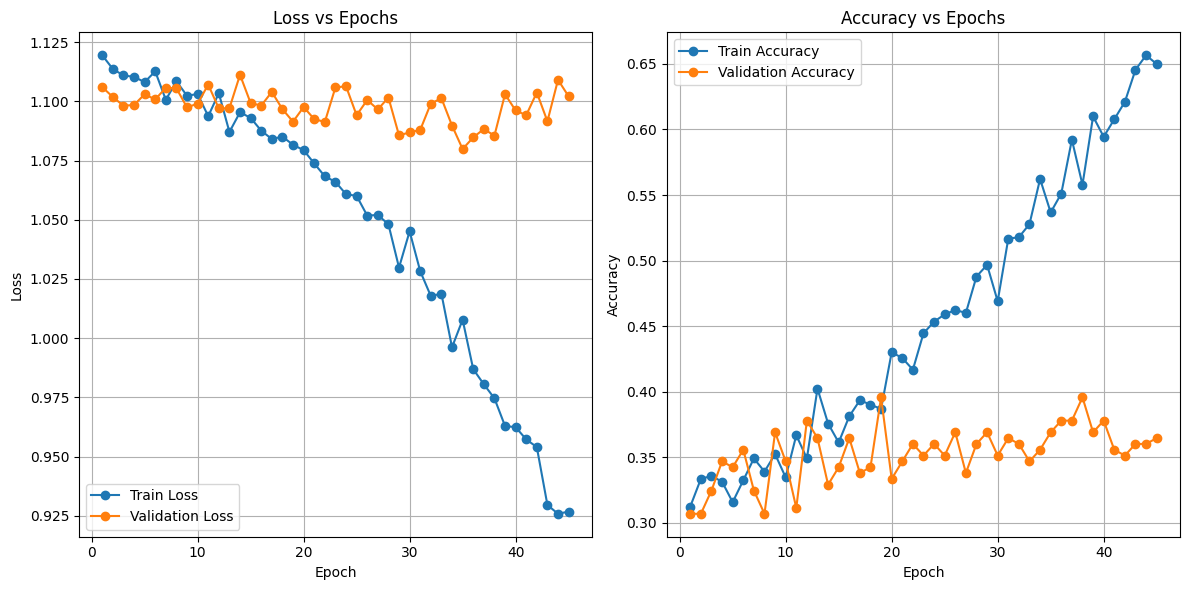

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1) Updated TCN Model with LeakyReLU, BatchNorm, and Dropout
class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=64, num_classes=3):
        super(TemporalConvNet, self).__init__()
        
        # Convolutional layers with pooling to reduce the temporal dimension
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(0.5)  # Added dropout layer
    
    def forward(self, x):
        # x shape: (batch_size, 64, time_length)
        x = F.leaky_relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.leaky_relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.leaky_relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.leaky_relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.leaky_relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)
        
        x = F.leaky_relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.leaky_relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)

        #check the documentation of pytorch
        return F.softmax(x, dim=1)

# 2) PyTorch Dataset for EEG using .vmrk files for marker extraction
class EEGBlock1Dataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files from a directory.
    For each file, the matching '.vmrk' file is parsed from vmrk_dir by replacing
    '_filtered_down.npy' with '.vmrk'. The .vmrk file is expected to contain lines
    with stimulus codes in the format: "MkX=Stimulus,Code,...".
    
    Marker mapping:
      S11, S110 -> 0 (Left)
      S12, S120 -> 1 (Right)
      S13       -> 2 (NoShock)
    
    The first three occurrences for each stimulus marker are removed.
    If there's a mismatch in the number of epochs vs. markers after filtering,
    the data is truncated.
    """
    def __init__(self, data_dir, file_list, vmrk_dir):
        super(EEGBlock1Dataset, self).__init__()
        self.X_all = []
        self.y_all = []
        self.code_to_label = {'S11': 0, 'S110': 0, 'S12': 1, 'S120': 1, 'S13': 2}
        
        for fname in file_list:
            # 1) Load the .npy EEG data
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)  # shape: (n_epochs, n_channels, n_times)
            n_epochs = data_3d.shape[0]
            
            # 2) Construct .vmrk path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk file found for {fname} at {vmrk_path}, skipping.")
                continue
            
            # 3) Parse the .vmrk file for stimulus codes using the filtered method
            marker_codes = self.parse_vmrk(vmrk_path)
            # 4) Remove the first three occurrences per individual stimulus marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # 5) Truncate if mismatch (if after filtering we still have a mismatch)
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # 6) Convert codes to numeric labels
            numeric_labels = [self.code_to_label[c] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        # Concatenate across files
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)  # shape: (total_epochs, n_channels, n_times)
            self.y_all = np.concatenate(self.y_all, axis=0)  # shape: (total_epochs,)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        """
        Reads the .vmrk file and extracts stimulus codes, returning only allowed codes.
        Each line starting with "Mk" and containing "Stimulus" is processed to extract
        the code (the second comma-separated value).
        """
        allowed_codes = ['S11', 'S110', 'S12', 'S120', 'S13']
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    code_str = parts[1].strip()
                    if code_str in allowed_codes:
                        codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        """
        Filters the list of marker codes by removing the first three occurrences for each individual stimulus marker.
        For each allowed marker (S11, S110, S12, S120, S13), skip the first three occurrences.
        """
        counts = {code: 0 for code in ['S11', 'S110', 'S12', 'S120', 'S13']}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences for this specific code
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        x_epoch = self.X_all[idx]  # shape: (n_channels, n_times)
        y_label = self.y_all[idx]
        return torch.from_numpy(x_epoch).float(), torch.tensor(y_label, dtype=torch.long)

# 3) Training & Validation Helper Function
def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc

# 4) Main Script
if __name__ == "__main__":
    train_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    val_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    test_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    vmrk_dir = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"
    
    train_files = [
        "01_ln_block1_filtered_down.npy",
        "02gd_block1_filtered_down.npy",
        "03as_block1_filtered_down.npy",
        "04ep_block1_filtered_down.npy",
        "06nc_block1_filtered_down.npy",
        "07fs_block1_filtered_down.npy",
        "08am_block1_filtered_down.npy",
        "09dm_block1_filtered_down.npy",
        "10lc_block1_filtered_down.npy",
        "11gb_block1_filtered_down.npy",
        "12ag_block1_filtered_down.npy",
        "13gc_block1_filtered_down.npy",
        "14es_block1_filtered_down.npy",
        "15kf_block1_filtered_down.npy",
        "16gd_block1_filtered_down.npy",
        "17st_block1_filtered_down.npy",
        "18gf_block1_filtered_down.npy",
        "19tm_block1_filtered_down.npy",
        "20md_block1_filtered_down.npy",
        "21es_block1_filtered_down.npy"
    ]
    val_files = [
        "23lp_block1_filtered_down.npy",
        "24cs_block1_filtered_down.npy",
        "25vt_block1_filtered_down.npy",
        "26fs_block1_filtered_down.npy",
        "27rv_block1_filtered_down.npy"
    ]
    test_files = [
        "28gv_block1_filtered_down.npy",
        "29bc_block1_filtered_down.npy",
        "30ss_block1_filtered_down.npy"
    ]
    
    train_dataset = EEGBlock1Dataset(train_dir, train_files, vmrk_dir)
    val_dataset = EEGBlock1Dataset(val_dir, val_files, vmrk_dir)
    test_dataset = EEGBlock1Dataset(test_dir, test_files, vmrk_dir)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    example_x, example_y = next(iter(train_loader))
    print("Example batch shape:", example_x.shape, example_y.shape)
    
    n_channels = example_x.shape[1]
    num_classes = 3
    
    model = TemporalConvNet(input_channels=n_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    n_epochs = 50  
    patience = 10  
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch} with Val Loss: {best_val_loss:.4f}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_model.pt")
    print("Model saved as tcn_block1_model.pt")
    
    epochs_range = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


Train dataset size: 900
Val dataset size:   225
Test dataset size:  135
Example batch shape: torch.Size([22, 64, 2250]) torch.Size([22])
TemporalConvNet(
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bat

C:\Users\Asus\miniconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 | Train Loss: 1.1114, Acc: 0.32 | Val Loss: 1.0990, Acc: 0.31
Epoch 2/50 | Train Loss: 1.1126, Acc: 0.33 | Val Loss: 1.1034, Acc: 0.31
Epoch 3/50 | Train Loss: 1.1181, Acc: 0.33 | Val Loss: 1.0998, Acc: 0.32
Epoch 4/50 | Train Loss: 1.1142, Acc: 0.32 | Val Loss: 1.1048, Acc: 0.31
Epoch 5/50 | Train Loss: 1.1072, Acc: 0.35 | Val Loss: 1.1029, Acc: 0.31
Epoch 6/50 | Train Loss: 1.1066, Acc: 0.35 | Val Loss: 1.1041, Acc: 0.32
Epoch 7/50 | Train Loss: 1.1118, Acc: 0.34 | Val Loss: 1.1018, Acc: 0.36
Epoch 8/50 | Train Loss: 1.1079, Acc: 0.37 | Val Loss: 1.1040, Acc: 0.32
Epoch 9/50 | Train Loss: 1.1123, Acc: 0.32 | Val Loss: 1.1010, Acc: 0.36
Epoch 10/50 | Train Loss: 1.1035, Acc: 0.35 | Val Loss: 1.1007, Acc: 0.36
Epoch 11/50 | Train Loss: 1.1041, Acc: 0.36 | Val Loss: 1.1005, Acc: 0.35
Early stopping triggered at epoch 11. Best epoch: 1 with Val Loss: 1.0990
Test Loss: 1.0971, Test Acc: 0.33
Model saved as tcn_block1_model.pt


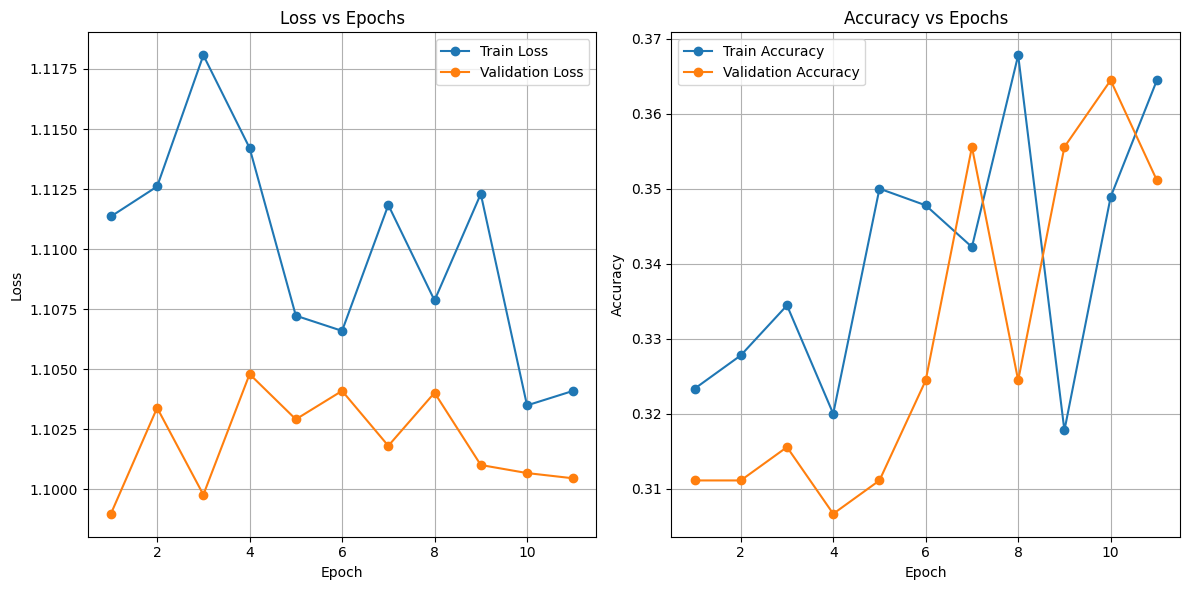

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1) Updated TCN Model with LeakyReLU, BatchNorm, and Dropout
class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=64, num_classes=3):
        super(TemporalConvNet, self).__init__()
        
        # Convolutional layers with pooling to reduce the temporal dimension
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(0.7)  # Added dropout layer
    
    def forward(self, x):
        # x shape: (batch_size, 64, time_length)
        x = F.leaky_relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.leaky_relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.leaky_relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.leaky_relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.leaky_relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)
        
        x = F.leaky_relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.leaky_relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return F.softmax(x, dim=1)

# 2) PyTorch Dataset for EEG using .vmrk files for marker extraction
class EEGBlock1Dataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files from a directory.
    For each file, the matching '.vmrk' file is parsed from vmrk_dir by replacing
    '_filtered_down.npy' with '.vmrk'. The .vmrk file is expected to contain lines
    with stimulus codes in the format: "MkX=Stimulus,Code,...".
    
    Marker mapping:
      S11, S110 -> 0 (Left)
      S12, S120 -> 1 (Right)
      S13       -> 2 (NoShock)
    
    The first three occurrences for each stimulus marker are removed.
    If there's a mismatch in the number of epochs vs. markers after filtering,
    the data is truncated.
    """
    def __init__(self, data_dir, file_list, vmrk_dir):
        super(EEGBlock1Dataset, self).__init__()
        self.X_all = []
        self.y_all = []
        self.code_to_label = {'S11': 0, 'S110': 0, 'S12': 1, 'S120': 1, 'S13': 2}
        
        for fname in file_list:
            # 1) Load the .npy EEG data
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)  # shape: (n_epochs, n_channels, n_times)
            n_epochs = data_3d.shape[0]
            
            # 2) Construct .vmrk path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk file found for {fname} at {vmrk_path}, skipping.")
                continue
            
            # 3) Parse the .vmrk file for stimulus codes using the filtered method
            marker_codes = self.parse_vmrk(vmrk_path)
            # 4) Remove the first three occurrences per individual stimulus marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # 5) Truncate if mismatch (if after filtering we still have a mismatch)
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # 6) Convert codes to numeric labels
            numeric_labels = [self.code_to_label[c] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        # Concatenate across files
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)  # shape: (total_epochs, n_channels, n_times)
            self.y_all = np.concatenate(self.y_all, axis=0)  # shape: (total_epochs,)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        """
        Reads the .vmrk file and extracts stimulus codes, returning only allowed codes.
        Each line starting with "Mk" and containing "Stimulus" is processed to extract
        the code (the second comma-separated value).
        """
        allowed_codes = ['S11', 'S110', 'S12', 'S120', 'S13']
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    code_str = parts[1].strip()
                    if code_str in allowed_codes:
                        codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        """
        Filters the list of marker codes by removing the first three occurrences for each individual stimulus marker.
        For each allowed marker (S11, S110, S12, S120, S13), skip the first three occurrences.
        """
        counts = {code: 0 for code in ['S11', 'S110', 'S12', 'S120', 'S13']}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences for this specific code
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        x_epoch = self.X_all[idx]  # shape: (n_channels, n_times)
        y_label = self.y_all[idx]
        return torch.from_numpy(x_epoch).float(), torch.tensor(y_label, dtype=torch.long)

# 3) Training & Validation Helper Function
def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc

# 4) Main Script
if __name__ == "__main__":
    train_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    val_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    test_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    vmrk_dir = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"
    
    train_files = [
        "01_ln_block1_filtered_down.npy",
        "02gd_block1_filtered_down.npy",
        "03as_block1_filtered_down.npy",
        "04ep_block1_filtered_down.npy",
        "06nc_block1_filtered_down.npy",
        "07fs_block1_filtered_down.npy",
        "08am_block1_filtered_down.npy",
        "09dm_block1_filtered_down.npy",
        "10lc_block1_filtered_down.npy",
        "11gb_block1_filtered_down.npy",
        "12ag_block1_filtered_down.npy",
        "13gc_block1_filtered_down.npy",
        "14es_block1_filtered_down.npy",
        "15kf_block1_filtered_down.npy",
        "16gd_block1_filtered_down.npy",
        "17st_block1_filtered_down.npy",
        "18gf_block1_filtered_down.npy",
        "19tm_block1_filtered_down.npy",
        "20md_block1_filtered_down.npy",
        "21es_block1_filtered_down.npy"
    ]
    val_files = [
        "23lp_block1_filtered_down.npy",
        "24cs_block1_filtered_down.npy",
        "25vt_block1_filtered_down.npy",
        "26fs_block1_filtered_down.npy",
        "27rv_block1_filtered_down.npy"
    ]
    test_files = [
        "28gv_block1_filtered_down.npy",
        "29bc_block1_filtered_down.npy",
        "30ss_block1_filtered_down.npy"
    ]
    
    train_dataset = EEGBlock1Dataset(train_dir, train_files, vmrk_dir)
    val_dataset = EEGBlock1Dataset(val_dir, val_files, vmrk_dir)
    test_dataset = EEGBlock1Dataset(test_dir, test_files, vmrk_dir)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    example_x, example_y = next(iter(train_loader))
    print("Example batch shape:", example_x.shape, example_y.shape)
    
    n_channels = example_x.shape[1]
    num_classes = 3
    
    model = TemporalConvNet(input_channels=n_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    # Increased weight decay to 1e-3
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    # Learning Rate Scheduler: Reduce LR on Plateau with factor 0.5 and patience 3
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    n_epochs = 50  
    patience = 10  
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        # Step the scheduler based on validation loss
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch} with Val Loss: {best_val_loss:.4f}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_model.pt")
    print("Model saved as tcn_block1_model.pt")
    
    epochs_range = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


Train dataset size: 900
Val dataset size:   225
Test dataset size:  135


C:\Users\Asus\miniconda3\Lib\site-packages\torch\functional.py:709: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window can are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\SpectralOps.cpp:842.)
  return _VF.stft(  # type: ignore[attr-defined]


Example batch shape (after STFT and reshaping): torch.Size([22, 8256, 36]) torch.Size([22])
New input channels (channels * freq bins): 8256
TemporalConvNet(
  (conv1): Conv1d(8256, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
 

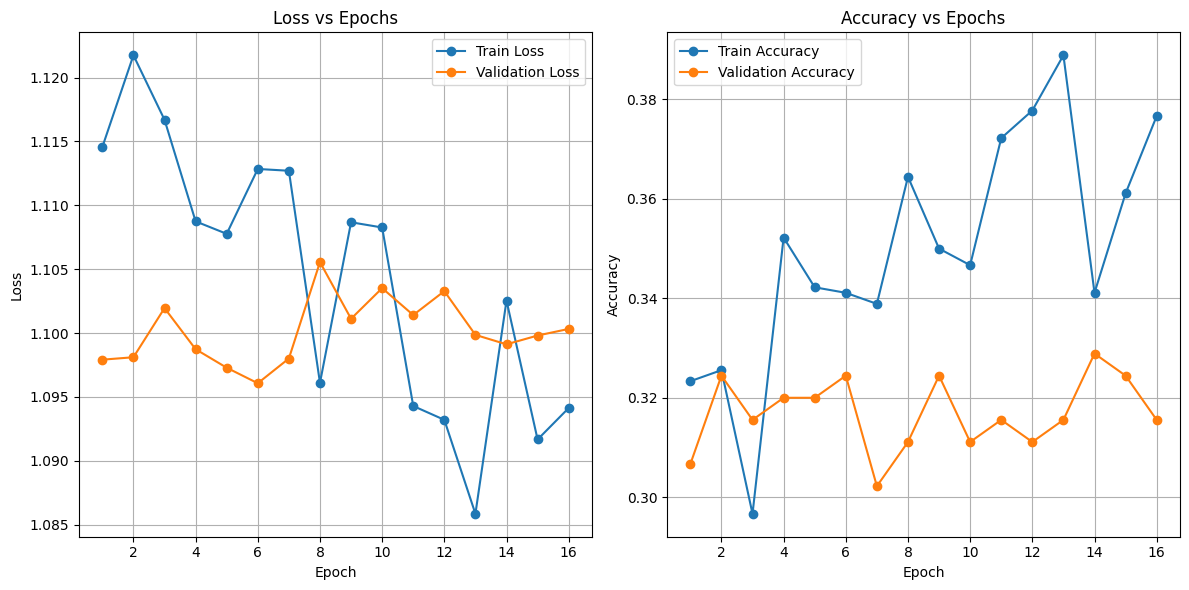

In [4]:
#STFT
import os
import re
import numpy as np
import yaml
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ========================
# 1) Revised TCN Model
# ========================
class TemporalConvNet(nn.Module):
    def __init__(self, input_channels, num_classes=3):
        super(TemporalConvNet, self).__init__()
        
        # Convolutional layers with pooling along the time axis.
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(0.7)
    
    def forward(self, x):
        # x shape: (batch_size, input_channels, time)
        x = F.leaky_relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.leaky_relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.leaky_relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.leaky_relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.leaky_relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)
        
        x = F.leaky_relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.leaky_relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return F.softmax(x, dim=1)


# 2) Revised EEGBlock1Dataset with STFT

class EEGBlock1Dataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files and their matching '.vmrk' files.
    Performs marker parsing and filtering as before, and then transforms each EEG epoch
    from 1D time series into a time–frequency representation using STFT.
    
    STFT Parameters:
      - n_fft: Number of FFT points (default=256)
      - hop_length: Hop length between successive frames (default=64)
      - win_length: Window length (default=256)
      
    The STFT is computed per channel and its magnitude is taken. Then the result (shape:
      [n_channels, time_frames, freq_bins])
    is reshaped into a 2D tensor of shape:
      [n_channels * freq_bins, time_frames]
    for input to 1D convolutions.
    """
    def __init__(self, data_dir, file_list, 2vmrk_dir, n_fft=256, hop_length=64, win_length=256):
        super(EEGBlock1Dataset, self).__init__()
        self.X_all = []
        self.y_all = []
        self.code_to_label = {'S11': 0, 'S110': 0, 'S12': 1, 'S120': 1, 'S13': 2}
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        
        for fname in file_list:
            # 1) Load the .npy EEG data (assumed shape: (n_epochs, n_channels, n_times))
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)
            n_epochs = data_3d.shape[0]
            
            # 2) Construct .vmrk path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk file found for {fname} at {vmrk_path}, skipping.")
                continue
            
            # 3) Parse the .vmrk file for stimulus codes
            marker_codes = self.parse_vmrk(vmrk_path)
            # 4) Filter markers: remove first three occurrences for each stimulus marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # 5) Check for mismatch between epochs and markers; truncate if needed
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # 6) Convert codes to numeric labels
            numeric_labels = [self.code_to_label[c] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)  # (total_epochs, n_channels, n_times)
            self.y_all = np.concatenate(self.y_all, axis=0)  # (total_epochs,)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        allowed_codes = ['S11', 'S110', 'S12', 'S120', 'S13']
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    code_str = parts[1].strip()
                    if code_str in allowed_codes:
                        codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        counts = {code: 0 for code in ['S11', 'S110', 'S12', 'S120', 'S13']}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences for this marker
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        # Get the raw epoch (shape: [n_channels, n_times])
        x_epoch = self.X_all[idx]
        y_label = self.y_all[idx]
        x_epoch = torch.from_numpy(x_epoch).float()
        
        # Compute STFT for each channel:
        stft_list = []
        for channel in x_epoch:  # channel is 1D tensor: [n_times]
            # Compute STFT; result shape: (freq_bins, time_frames)
            stft_channel = torch.stft(channel, n_fft=self.n_fft, hop_length=self.hop_length, 
                                        win_length=self.win_length, return_complex=True)
            # Take magnitude
            stft_channel = torch.abs(stft_channel)  # shape: (freq_bins, time_frames)
            # Transpose to have time along the first dimension: (time_frames, freq_bins)
            stft_channel = stft_channel.transpose(0, 1)
            stft_list.append(stft_channel)
        # Stack across channels: shape becomes (n_channels, time_frames, freq_bins)
        x_stft = torch.stack(stft_list, dim=0)
        # Combine the frequency dimension with the channel dimension:
        # Permute to (n_channels, freq_bins, time_frames) then reshape to (n_channels * freq_bins, time_frames)
        n_channels, time_frames, freq_bins = x_stft.shape
        x_stft = x_stft.permute(0, 2, 1).reshape(n_channels * freq_bins, time_frames)
        
        # Return the transformed epoch and the label
        return x_stft, torch.tensor(y_label, dtype=torch.long)


# 3) Training & Validation Pipeline

def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc

if __name__ == "__main__":
    # Directories
    train_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    val_dir   = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    test_dir  = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ"
    vmrk_dir  = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"
    
    # File lists (update these lists as needed)
    train_files = [
        "01_ln_block1_filtered_down.npy",
        "02gd_block1_filtered_down.npy",
        "03as_block1_filtered_down.npy",
        "04ep_block1_filtered_down.npy",
        "06nc_block1_filtered_down.npy",
        "07fs_block1_filtered_down.npy",
        "08am_block1_filtered_down.npy",
        "09dm_block1_filtered_down.npy",
        "10lc_block1_filtered_down.npy",
        "11gb_block1_filtered_down.npy",
        "12ag_block1_filtered_down.npy",
        "13gc_block1_filtered_down.npy",
        "14es_block1_filtered_down.npy",
        "15kf_block1_filtered_down.npy",
        "16gd_block1_filtered_down.npy",
        "17st_block1_filtered_down.npy",
        "18gf_block1_filtered_down.npy",
        "19tm_block1_filtered_down.npy",
        "20md_block1_filtered_down.npy",
        "21es_block1_filtered_down.npy"
    ]
    val_files = [
        "23lp_block1_filtered_down.npy",
        "24cs_block1_filtered_down.npy",
        "25vt_block1_filtered_down.npy",
        "26fs_block1_filtered_down.npy",
        "27rv_block1_filtered_down.npy"
    ]
    test_files = [
        "28gv_block1_filtered_down.npy",
        "29bc_block1_filtered_down.npy",
        "30ss_block1_filtered_down.npy"
    ]
    
    # Create datasets with STFT parameters (you can adjust n_fft, hop_length, win_length as needed)
    train_dataset = EEGBlock1Dataset(train_dir, train_files, vmrk_dir, n_fft=256, hop_length=64, win_length=256)
    val_dataset   = EEGBlock1Dataset(val_dir, val_files, vmrk_dir, n_fft=256, hop_length=64, win_length=256)
    test_dataset  = EEGBlock1Dataset(test_dir, test_files, vmrk_dir, n_fft=256, hop_length=64, win_length=256)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    # Get an example batch to determine new input channels (after STFT transformation)
    example_x, example_y = next(iter(train_loader))
    print("Example batch shape (after STFT and reshaping):", example_x.shape, example_y.shape)
    # example_x shape: (batch, new_input_channels, time_frames)
    n_input_channels = example_x.shape[1]
    print("New input channels (channels * freq bins):", n_input_channels)
    
    num_classes = 3
    model = TemporalConvNet(input_channels=n_input_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    n_epochs = 50  
    patience = 10  
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch} with Val Loss: {best_val_loss:.4f}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_model.pt")
    print("Model saved as tcn_block1_model.pt")
    
    epochs_range = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
